In [5]:
import requests
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image as PILImage
import numpy as np
from io import BytesIO


In [ ]:

# GROUP_ID looks like "-203400-203401-..." 
# extract player IDs from your a lineup and test a headshot

adv_df = pd.read_csv('../data/raw/storm_lineups_advanced.csv')

# Find your best lineup by net rating with 100+ possessions
best_lineups = adv_df[adv_df['POSS'] >= 100].nlargest(5, 'NET_RATING')[['GROUP_NAME', 'GROUP_ID', 'NET_RATING', 'POSS', 'SEASON']]
print(best_lineups)

# Extract player IDs from GROUP_ID of the top lineup
top_lineup = best_lineups.iloc[0]
player_ids = [pid for pid in top_lineup['GROUP_ID'].split('-') if pid.strip()]
print(f"\nPlayer IDs: {player_ids}")

# Test headshot URL for first player
test_id = player_ids[0]
url = f"https://ak-static.cms.nba.com/wp-content/uploads/headshots/wnba/latest/260x190/{test_id}.png"
print(f"\nTesting URL: {url}")

response = requests.get(url)
print(f"Status code: {response.status_code}")
if response.status_code == 200:
    display(Image(url=url))
else:
    print("Headshot not found at this URL")

In [2]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Referer': 'https://www.wnba.com/'
}

# Also try a few different URL patterns
test_id = player_ids[0]
urls = [
    f"https://ak-static.cms.nba.com/wp-content/uploads/headshots/wnba/latest/260x190/{test_id}.png",
    f"https://cdn.nba.com/headshots/wnba/latest/260x190/{test_id}.png",
    f"https://cdn.wnba.com/headshots/wnba/latest/260x190/{test_id}.png",
]

for url in urls:
    response = requests.get(url, headers=headers)
    print(f"{url}")
    print(f"  Status: {response.status_code}\n")

https://ak-static.cms.nba.com/wp-content/uploads/headshots/wnba/latest/260x190/100484.png
  Status: 403

https://cdn.nba.com/headshots/wnba/latest/260x190/100484.png
  Status: 403

https://cdn.wnba.com/headshots/wnba/latest/260x190/100484.png
  Status: 200



In [3]:
from IPython.display import Image, display

url = f"https://cdn.wnba.com/headshots/wnba/latest/260x190/{test_id}.png"
response = requests.get(url, headers=headers)

if response.status_code == 200:
    display(Image(url=url))
else:
    print(f"Failed: {response.status_code}")


# If this returns a headshot we're good to build the full graphic. The URL pattern for every player will be:

# https://cdn.wnba.com/headshots/wnba/latest/260x190/{player_id}.png

In [4]:
# Check what season the top lineup is from
print(best_lineups[['GROUP_NAME', 'GROUP_ID', 'NET_RATING', 'POSS', 'SEASON']].head())

# Also test a known current Storm player
# Ezi Magbegor, Jewell Loyd, others from recent seasons
# Let's find player IDs from 2025 specifically
recent_lineups = adv_df[adv_df['SEASON'] == 2025].nlargest(3, 'POSS')[['GROUP_NAME', 'GROUP_ID']]
print("\n2025 top lineups:")
print(recent_lineups)

# Extract and test IDs from a 2024 lineup
recent_ids = [pid for pid in recent_lineups.iloc[0]['GROUP_ID'].split('-') if pid.strip()]
print(f"\n2025 player IDs: {recent_ids}")

for pid in recent_ids:
    url = f"https://cdn.wnba.com/headshots/wnba/latest/260x190/{pid}.png"
    response = requests.get(url, headers=headers)
    print(f"{pid}: {response.status_code}")
    if response.status_code == 200:
        display(Image(url=url))

                                             GROUP_NAME  \
1363  B. Lennox - L. Jackson - S. Bird - I. Castro M...   
2001  S. Abrosimova - L. Jackson - S. Bird - S. Cash...   
1349  B. Lennox - J. Burse - L. Jackson - S. Bird - ...   
1347  T. Johnson - B. Lennox - L. Jackson - S. Bird ...   
1364  W. Palmer - B. Lennox - L. Jackson - S. Bird -...   

                                  GROUP_ID  NET_RATING  POSS  SEASON  
1363  -100484-100682-100720-100796-100942-        61.0   147    2007  
2001  -100658-100682-100720-100721-201067-        34.2   109    2010  
1349  -100484-100660-100682-100720-200681-        27.9   182    2006  
1347  -100233-100484-100682-100720-200681-        25.5   118    2006  
1364  -100046-100484-100682-100720-100796-        25.0   113    2007  

2025 top lineups:
                                             GROUP_NAME  \
4100  N. Ogwumike - S. Diggins - E. Wheeler - G. Wil...   
4101  N. Ogwumike - S. Diggins - B. Sykes - G. Willi...   
4102  A. Clark - N. Ogw

203400: 200


204365: 200


1628931: 200


1629496: 200


In [7]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
    'Referer': 'https://www.wnba.com/'
}

# ---- Step 1: Find top 5 lineups in franchise history ----
top10 = (adv_df[adv_df['POSS'] >= 100]
        .nlargest(10, 'NET_RATING')
        [['SEASON', 'GROUP_NAME', 'GROUP_ID', 'NET_RATING', 'OFF_RATING', 'DEF_RATING', 'POSS']]
        .reset_index(drop=True))

print(top10)

   SEASON                                         GROUP_NAME  \
0    2007  B. Lennox - L. Jackson - S. Bird - I. Castro M...   
1    2010  S. Abrosimova - L. Jackson - S. Bird - S. Cash...   
2    2006  B. Lennox - J. Burse - L. Jackson - S. Bird - ...   
3    2006  T. Johnson - B. Lennox - L. Jackson - S. Bird ...   
4    2007  W. Palmer - B. Lennox - L. Jackson - S. Bird -...   
5    2018  S. Bird - N. Howard - J. Loyd - K. Mosqueda-Le...   
6    2020  S. Bird - A. Clark - N. Howard - J. Loyd - B. ...   
7    2009  J. Burse - L. Jackson - S. Bird - S. Cash - T....   
8    2023  J. Loyd - S. Whitcomb - G. Williams - E. Magbe...   
9    2022  S. Bird - T. Charles - J. Loyd - B. Stewart - ...   

                                   GROUP_ID  NET_RATING  OFF_RATING  \
0      -100484-100682-100720-100796-100942-        61.0       125.2   
1      -100658-100682-100720-100721-201067-        34.2       116.5   
2      -100484-100660-100682-100720-200681-        27.9       111.0   
3      -100

C:\Users\casey\AppData\Local\Temp\ipykernel_23284\949288485.py:154: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/storm_top10_lineups.png',
c:\Users\casey\anaconda3\envs\wnba\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


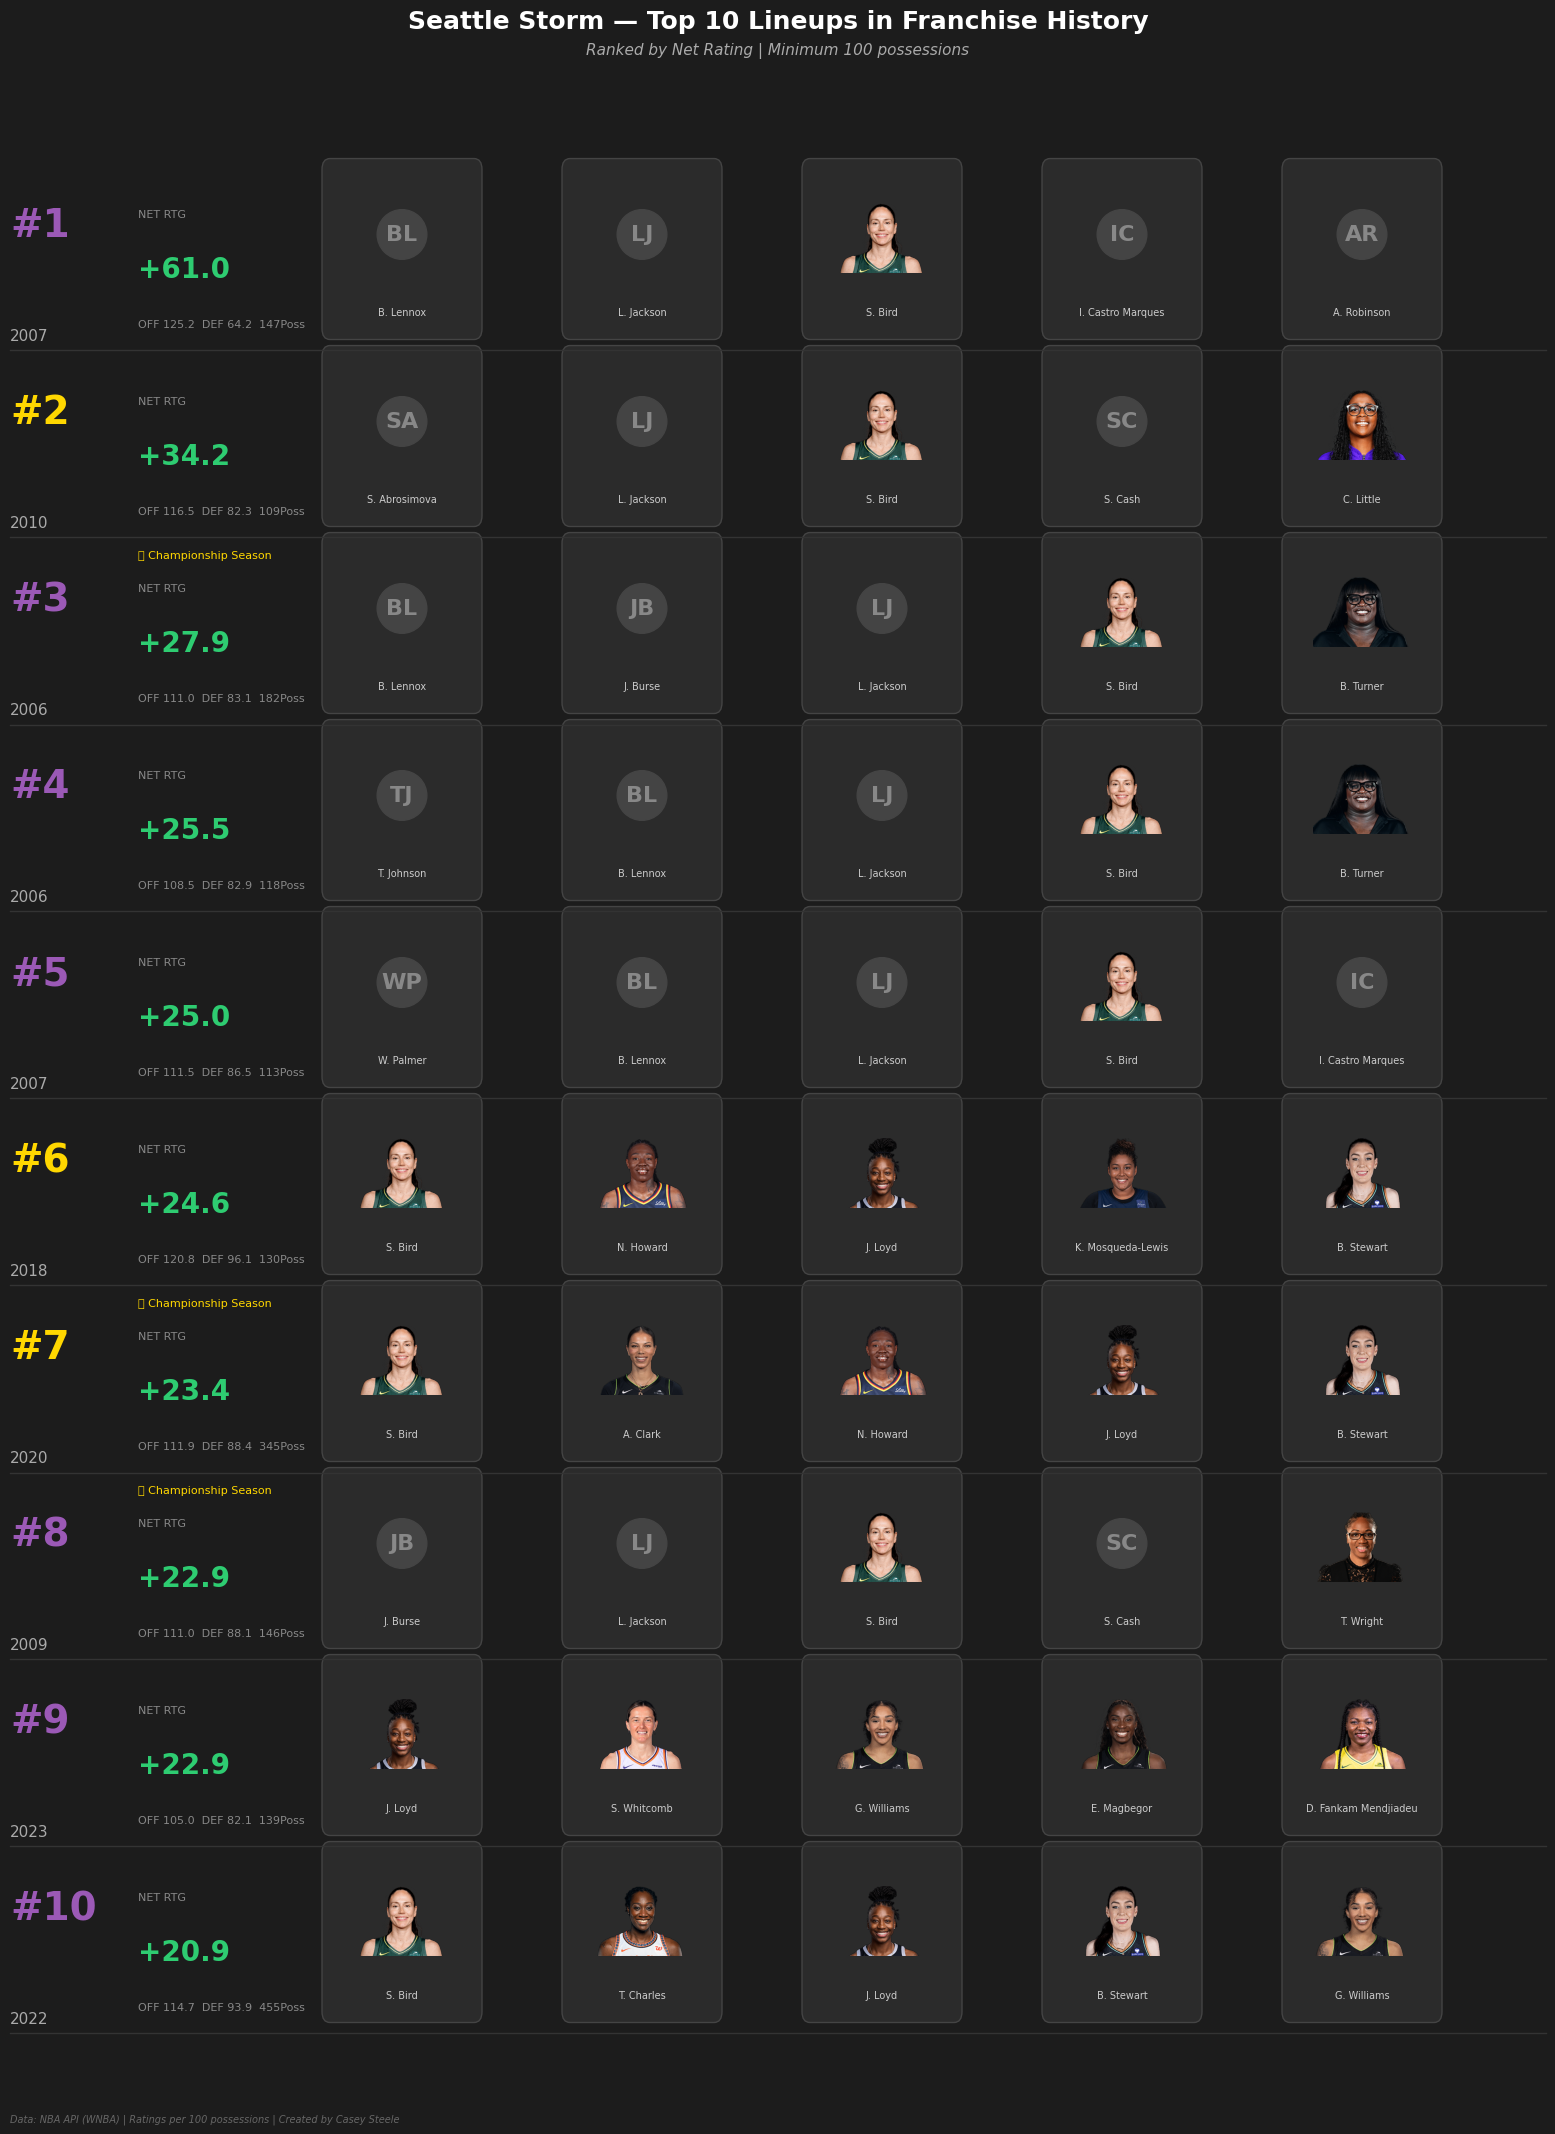

Saved to ../outputs/storm_top10_lineups.png


In [15]:
# ---- Step 2: Headshot fetcher ----
def get_headshot(player_id, player_name):
    url = f"https://cdn.wnba.com/headshots/wnba/latest/260x190/{player_id}.png"
    try:
        response = requests.get(url, headers=headers, timeout=5)
        if response.status_code == 200:
            if len(response.content) < 5000:  # placeholder silhouette
                return None, True
            img = PILImage.open(BytesIO(response.content)).convert('RGBA')
            arr = np.array(img)
            return arr, False
    except:
        pass
    return None, True

# ---- Step 3: Parse player names and IDs ----
def parse_lineup(row):
    names = [n.strip() for n in row['GROUP_NAME'].split(' - ')]
    ids = [pid for pid in row['GROUP_ID'].split('-') if pid.strip()]
    return list(zip(names, ids))

# ---- Step 4: Build the graphic ----
def build_top10_graphic(top5):
    fig = plt.figure(figsize=(16, 22))
    fig.patch.set_facecolor('#1c1c1c')
    
    # Title
    fig.text(0.5, 0.97,
             'Seattle Storm — Top 10 Lineups in Franchise History',
             ha='center', va='top',
             fontsize=18, fontweight='bold', color='white')
    fig.text(0.5, 0.955,
             'Ranked by Net Rating | Minimum 100 possessions',
             ha='center', va='top',
             fontsize=11, color='#aaaaaa', style='italic')
    
    n_lineups = len(top10)
    row_height = 0.85 / n_lineups
    
    for lineup_idx, lineup_row in top5.iterrows():
        players = parse_lineup(lineup_row)
        y_top = 0.93 - (lineup_idx * row_height) - 0.04
        y_center = y_top - (row_height * 0.45)
        
        # Lineup rank and stats bar
        is_champ_season = lineup_row['SEASON'] in [2004, 2010, 2018, 2020]
        rank_color = 'gold' if is_champ_season else '#9b59b6'
        
        # Rank number
        fig.text(0.02, y_center + 0.02,
                 f"#{lineup_idx + 1}",
                 fontsize=28, fontweight='bold',
                 color=rank_color, va='center')
        
        # Season
        fig.text(0.02, y_center - 0.03,
                 f"{int(lineup_row['SEASON'])}",
                 fontsize=11, color='#aaaaaa', va='center')
        
        # Stats
        stats_x = 0.10
        fig.text(stats_x, y_center + 0.025,
                 f"NET RTG",
                 fontsize=8, color='#888888', va='center')
        fig.text(stats_x, y_center,
                 f"{lineup_row['NET_RATING']:+.1f}",
                 fontsize=20, fontweight='bold',
                 color='#2ecc71' if lineup_row['NET_RATING'] > 0 else '#e74c3c',
                 va='center')
        
        fig.text(stats_x, y_center - 0.025,
                 f"OFF {lineup_row['OFF_RATING']:.1f}  DEF {lineup_row['DEF_RATING']:.1f}  {int(lineup_row['POSS'])}Poss",
                 fontsize=8, color='#888888', va='center')
        
        # Championship marker
        if is_champ_season:
            fig.text(stats_x, y_center - 0.045,
                     '🏆 Championship Season',
                     fontsize=8, color='gold', va='center')
        
        # Divider line
        line = plt.Line2D([0.02, 0.98],
                          [y_top - row_height + 0.01,
                           y_top - row_height + 0.01],
                          transform=fig.transFigure,
                          color='#333333', linewidth=1)
        fig.add_artist(line)
        
        # Player headshots
        n_players = len(players)
        headshot_start_x = 0.22
        headshot_spacing = 0.15
        headshot_width = 0.09
        headshot_height = row_height * 0.85
        
        for p_idx, (name, pid) in enumerate(players):
            x_left = headshot_start_x + (p_idx * headshot_spacing)
            x_center_p = x_left + headshot_width / 2
            
            # Player card background
            card = mpatches.FancyBboxPatch(
                (x_left, y_top - row_height + 0.02),
                headshot_width, headshot_height,
                boxstyle='round,pad=0.005',
                facecolor='#2b2b2b',
                edgecolor='#444444',
                linewidth=1,
                transform=fig.transFigure
            )
            fig.add_artist(card)
            
            # Fetch headshot
            img_arr, is_silhouette = get_headshot(pid, name)
            
            ax_img = fig.add_axes([
                x_left + 0.005,
                y_top - row_height + 0.045,
                headshot_width - 0.01,
                headshot_height - 0.04
            ], zorder=10)  # force on top
            ax_img.set_facecolor('#2b2b2b')
            ax_img.axis('off')

            if img_arr is not None and not is_silhouette:
                ax_img.imshow(img_arr, aspect='equal', zorder=11)
            else:
                ax_img.set_xlim(0, 1)
                ax_img.set_ylim(0, 1)
                ax_img.set_facecolor('#333333')
                initials = ''.join([n[0] for n in name.replace('.', '').strip().split() if n])
                circle = plt.Circle((0.5, 0.55), 0.35, color='#444444', zorder=12)
                ax_img.add_patch(circle)
                ax_img.text(0.5, 0.55, initials[:2].upper(),
                            ha='center', va='center',
                            fontsize=16, fontweight='bold',
                            color='#888888', zorder=13)
                
            ax_img.set_aspect('equal')
            
            # Player name below card
            # Shorten name for display
            short_name = name.strip()
            fig.text(x_center_p, y_top - row_height + 0.025,
                     short_name,
                     ha='center', va='bottom',
                     fontsize=7, color='#cccccc',
                     transform=fig.transFigure)
    
    # Footnote
    fig.text(0.02, 0.01,
             'Data: NBA API (WNBA) | Ratings per 100 possessions | Created by Casey Steele',
             fontsize=7, color='#666666', style='italic')
    
    plt.savefig('../outputs/storm_top10_lineups.png',
                dpi=150, bbox_inches='tight',
                facecolor='#1c1c1c')
    plt.show()
    print("Saved to ../outputs/storm_top10_lineups.png")

build_top10_graphic(top10)

In [10]:
# Get player IDs from your top lineup
players = parse_lineup(top10.iloc[0])
print("Players and IDs:")
for name, pid in players:
    print(f"  {name}: {pid}")
    url = f"https://cdn.wnba.com/headshots/wnba/latest/260x190/{pid}.png"
    response = requests.get(url, headers=headers, timeout=5)
    print(f"  Status: {response.status_code}, Size: {len(response.content)} bytes")

Players and IDs:
  B. Lennox: 100484
  Status: 200, Size: 4030 bytes
  L. Jackson: 100682
  Status: 200, Size: 4030 bytes
  S. Bird: 100720
  Status: 200, Size: 18305 bytes
  I. Castro Marques: 100796
  Status: 200, Size: 4030 bytes
  A. Robinson: 100942
  Status: 200, Size: 4030 bytes


B. Lennox: silhouette=True, arr=False
L. Jackson: silhouette=True, arr=False
S. Bird: silhouette=False, arr=True


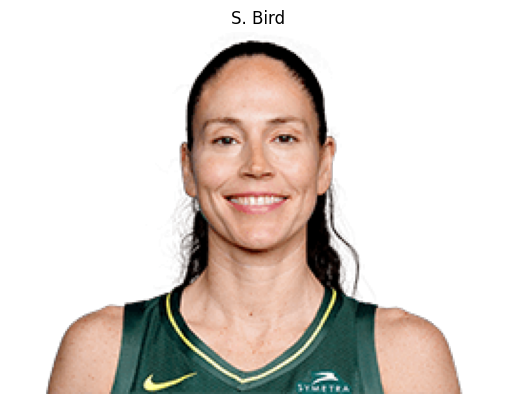

In [13]:
# Quick isolated test
players = parse_lineup(top10.iloc[0])
for name, pid in players:
    img_arr, is_sil = get_headshot(pid, name)
    print(f"{name}: silhouette={is_sil}, arr={img_arr is not None}")
    if img_arr is not None:
        fig_test, ax_test = plt.subplots()
        ax_test.imshow(img_arr)
        ax_test.axis('off')
        plt.title(name)
        plt.show()
        break